# 1.2 FIR filter на 16-битных числах

Тот же bandpass 2500–3500 Hz, но в арифметике, в которой реально будет работать FPGA. С микрофона INMP441 по I2S приходят `int16`, и держать там float64 — не вариант: float-умножители занимают сотни LUT, а int16 × int16 — один встроенный DSP-блок.

По ТЗ три варианта чисел: `float16`, **fixed point Q1.15** (это и есть нормальный вариант) и `integer`. Прогоняем фильтр в каждом из них и сравниваем с эталоном.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, spectrogram
from IPython.display import Audio, display

from filter_anc.signals import (
    synth_music, music_with_beep, white_noise, load_wav, to_int16, from_int16,
)

FS = 48_000
F1, F2 = 2_500, 3_500
N = 101

## 1.2.1 три варианта 16-бит фильтра

Берём эталонные коэффициенты `firwin` (float64) и квантуем их три раза.

**Q1.15** — это просто целый int16, который интерпретируется как число в `[-1, 1)`. Перевод: `q = round(x * 2^15)`, обратно: `x = q / 2^15`. Разрешение `2^-15 ≈ 3e-5`, для аудио более чем достаточно.

Сам FIR на Q1.15 расписываю руками, чтобы было понятно, что внутри. Псевдокод того, что будет в Verilog:

```
acc = sum(x[n-k] * b[k] for k in 0..N-1)    # int16 × int16, копим в int64
y[n] = saturate_i16((acc + (1<<14)) >> 15)  # обратно в Q1.15 + saturation
```

In [2]:
b_f64 = firwin(N, [F1, F2], pass_zero=False, window="hamming", fs=FS)

b_f16 = b_f64.astype(np.float16)
b_q15 = np.round(b_f64 * 2**15).astype(np.int16)
b_int = np.round(b_f64 * 2**15).astype(np.int32)   # scale_bits = 15

print(f"float16  min/max: {b_f16.min():+.5f} / {b_f16.max():+.5f}")
print(f"Q1.15    min/max: {int(b_q15.min()):+d} / {int(b_q15.max()):+d}")
print(f"integer  min/max: {int(b_int.min()):+d} / {int(b_int.max()):+d}  (scale=2^15)")

float16  min/max: -0.04352 / +0.04831
Q1.15    min/max: -1426 / +1583
integer  min/max: -1426 / +1583  (scale=2^15)


In [3]:
def fir_q15(b_q15, x_i16):
    # np.convolve в int64 = тот же direct-form FIR без потери точности
    full = np.convolve(x_i16.astype(np.int64), b_q15.astype(np.int64), mode="full")[:len(x_i16)]
    y = (full + (1 << 14)) >> 15
    return np.clip(y, -32768, 32767).astype(np.int16)

def fir_int(b_int, x_i16, scale_bits=15):
    full = np.convolve(x_i16.astype(np.int64), b_int.astype(np.int64), mode="full")[:len(x_i16)]
    y = (full + (1 << (scale_bits - 1))) >> scale_bits
    return np.clip(y, -32768, 32767).astype(np.int16)

def fir_f16(b_f16, x_f16):
    # У float16 такой маленький динамический диапазон, что аккумулятор тоже надо
    # держать в float16 — так и будет на FPGA, если кто-то решит её использовать
    return np.convolve(x_f16, b_f16, mode="full")[:len(x_f16)].astype(np.float16)

## 1.2.2 характеристики после квантования

Главное — проверить, что АЧХ не сломалась после квантования. Если она поехала или появились странные горбы, значит число бит не хватает. Для нашего фильтра коэффициенты влезают в `[-1, 1)`, так что Q1.15 должен совпасть с float64 почти один в один.

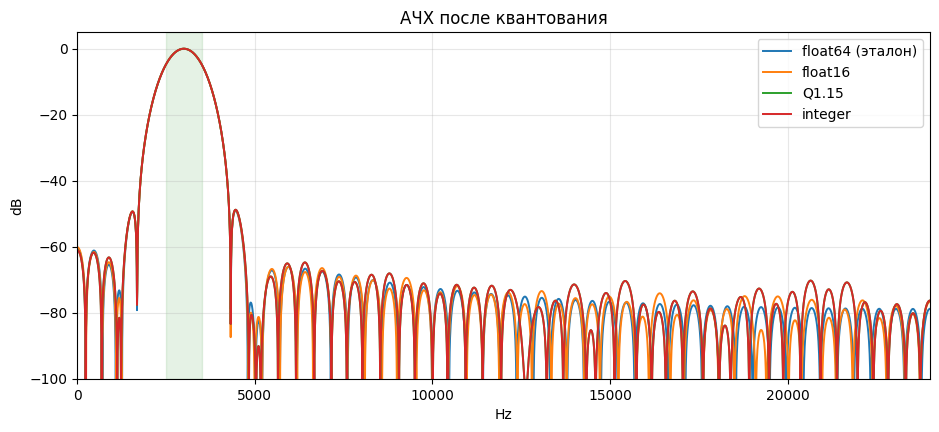

In [4]:
variants = {
    "float64 (эталон)": b_f64,
    "float16":          b_f16.astype(np.float64),
    "Q1.15":            b_q15.astype(np.float64) / 2**15,
    "integer":          b_int.astype(np.float64) / 2**15,
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for name, b in variants.items():
    w, h = freqz(b, worN=4096, fs=FS)
    ax.plot(w, 20*np.log10(np.abs(h)+1e-12), label=name, linewidth=1.4)
ax.axvspan(F1, F2, alpha=0.1, color="g")
ax.set_xlim(0, FS/2); ax.set_ylim(-100, 5)
ax.set_xlabel("Hz"); ax.set_ylabel("dB"); ax.set_title("АЧХ после квантования")
ax.legend(); ax.grid(alpha=.3)
plt.show()

Q1.15 и integer кладутся ровно поверх float64. float16 чуть отъезжает в стоп-полосе (его 10 бит мантиссы хуже, чем 15 битов Q1.15), но в полосе пропускания всё нормально.

## 1.2.3 эксперименты на int16

Те же три сигнала, но через `to_int16` приводятся к 16-битному виду (как с микрофона) и прогоняются через **Q1.15**-фильтр. Это уже репетиция того, что услышит FPGA.

In [5]:
data = Path.cwd().parent / "data"
if (data / "music.wav").exists():
    music, _ = load_wav(data / "music.wav")
    beep,  _ = load_wav(data / "music_beep.wav")
    noise, _ = load_wav(data / "white_noise.wav")
else:
    music = synth_music(5, FS)
    beep  = music_with_beep(5, FS, beep_hz=3_000)
    noise = white_noise(5, FS)

sigs = {"I. music": music, "II. music+beep": beep, "III. noise": noise}
sigs_i16 = {k: to_int16(v) for k, v in sigs.items()}
out_q15  = {k: fir_q15(b_q15, v) for k, v in sigs_i16.items()}

# Заодно сравним с эталоном float64, чтобы убедиться что Q1.15 не врёт
from scipy.signal import lfilter
out_f64  = {k: lfilter(b_f64, [1.0], v) for k, v in sigs.items()}
for k in sigs:
    a = out_f64[k]
    b = from_int16(out_q15[k])
    print(f"{k:<20s} corr(float64, Q1.15) = {np.corrcoef(a, b)[0,1]:.5f}")

I. music             corr(float64, Q1.15) = 0.99944
II. music+beep       corr(float64, Q1.15) = 1.00000
III. noise           corr(float64, Q1.15) = 1.00000


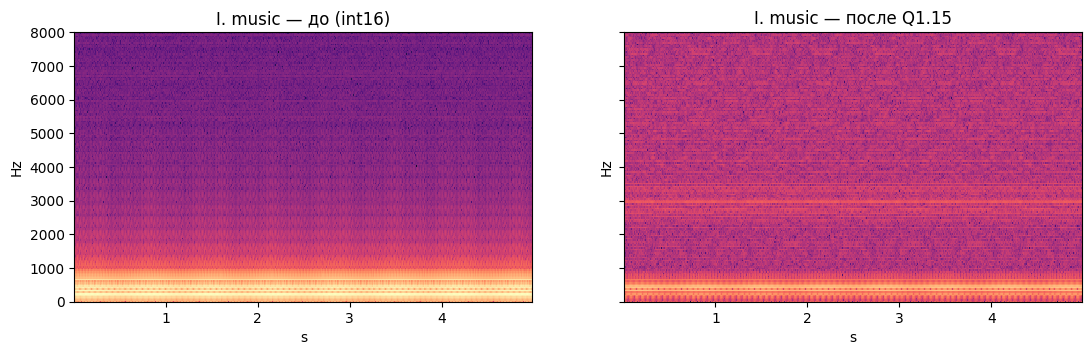

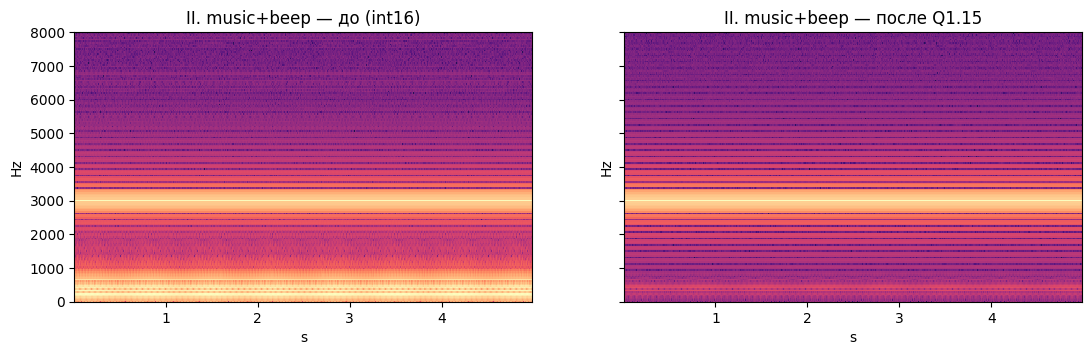

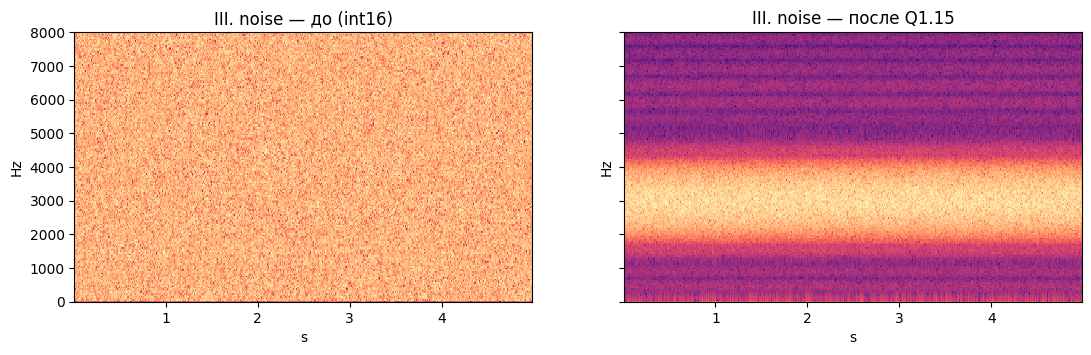

In [6]:
def spec(ax, x, title):
    f, t, S = spectrogram(x.astype(np.float64), fs=FS, nperseg=1024, noverlap=512)
    ax.pcolormesh(t, f, 10*np.log10(S+1e-12), shading="auto", cmap="magma")
    ax.set_ylim(0, 8000); ax.set_title(title); ax.set_xlabel("s"); ax.set_ylabel("Hz")

for name in sigs:
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
    spec(ax[0], sigs_i16[name], f"{name} — до (int16)")
    spec(ax[1], out_q15[name],  f"{name} — после Q1.15")
    plt.show()

In [7]:
for name in sigs:
    print(name)
    display(Audio(sigs_i16[name], rate=FS, normalize=True))
    display(Audio(out_q15[name],  rate=FS, normalize=True))

I. music


II. music+beep


III. noise


### итого

Корреляция Q1.15 с float64-эталоном — практически 1.0, спектрограммы такие же, как в эталонной версии, ничего не переполняется. Значит коэффициенты `b_q15` можно без потерь забирать в Verilog как `int16` массив, и FPGA-фильтр должен звучать так же.